# Práctica 02: selecciones y variables de calidad con Uproot

Versión modular compatible con Windows. Uproot realiza la lectura, NumPy los cortes, Matplotlib las gráficas y SciPy el ajuste.

In [2]:
from pathlib import Path
import sys

# Funciona si VS Code inicia el kernel en la raíz del repositorio o en Dec_Bpm.
module_candidates = (
    Path.cwd(),
    Path.cwd() / "Pruebas" / "Dec_Bpm",
)
for candidate in module_candidates:
    if (candidate / "modulos").is_dir():
        analysis_dir = candidate.resolve()
        break
else:
    raise FileNotFoundError(
        "No se encontró la carpeta ecfm_uproot. Copia el paquete junto a los notebooks."
    )

if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

print("Intérprete de Python:", sys.executable)

import numpy as np
import pandas as pd

from modulos import (
    build_cutflow,
    estimate_sideband_background,
    in_window,
    list_branches,
    load_arrays,
    print_cutflow,
)
from modulos.fitting import fit_and_plot, gaussian
from modulos.plotting import plot_hist1d, plot_hist2d, plot_hist_comparison

columns = list_branches()
arrays = load_arrays(
    [
        "Bplus_M",
        "J_psi_1S_M",
        "Bplus_PT",
        "Bplus_ENDVERTEX_CHI2",
        "Kplus_PIDK",
    ]
)

b_mass = arrays["Bplus_M"]
jpsi_mass = arrays["J_psi_1S_M"]
b_pt = arrays["Bplus_PT"]
b_vertex_chi2 = arrays["Bplus_ENDVERTEX_CHI2"]
kplus_pidk = arrays["Kplus_PIDK"]

print(f"Candidatos cargados: {len(b_mass):,}")


Intérprete de Python: c:\Users\mario\AppData\Local\Programs\Python\Python312\python.exe
Candidatos cargados: 5,428,778


## Conteo de candidatos

In [3]:
mask_jpsi = in_window(jpsi_mass, 3050, 3150)
mask_b_window = in_window(b_mass, 5150, 5400)

cutflow = build_cutflow(
    len(b_mass),
    {
        "Ventana de masa J/psi": mask_jpsi,
        "J/psi + ventana de masa B": mask_jpsi & mask_b_window,
    },
)
print_cutflow(cutflow)


Inicial                        :  5,428,778 (100.00 % del total)
Ventana de masa J/psi          :  5,191,777 ( 95.63 % del total)
J/psi + ventana de masa B      :  2,583,536 ( 47.59 % del total)


## Masa B antes y después del corte en $J/\psi$

Se corrigió el original: el segundo histograma ahora usa realmente los candidatos filtrados.

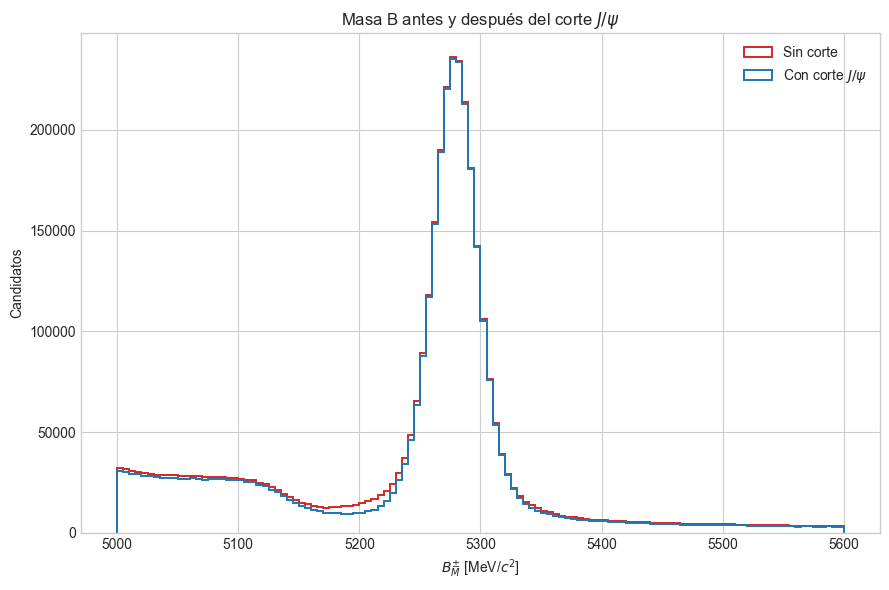

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Masa B antes y después del corte $J/\\psi$'}, xlabel='$B^{\\pm}_M$ [MeV/$c^2$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p02_bmasa_vs_jpsi_uproot.png'))

In [4]:
plot_hist_comparison(
    {
        "Sin corte": b_mass,
        r"Con corte $J/\psi$": b_mass[mask_jpsi],
    },
    bins=120,
    value_range=(5000, 5600),
    title=r"Masa B antes y después del corte $J/\psi$",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p02_bmasa_vs_jpsi_uproot.png",
)


## Ajuste del pico de masa del B

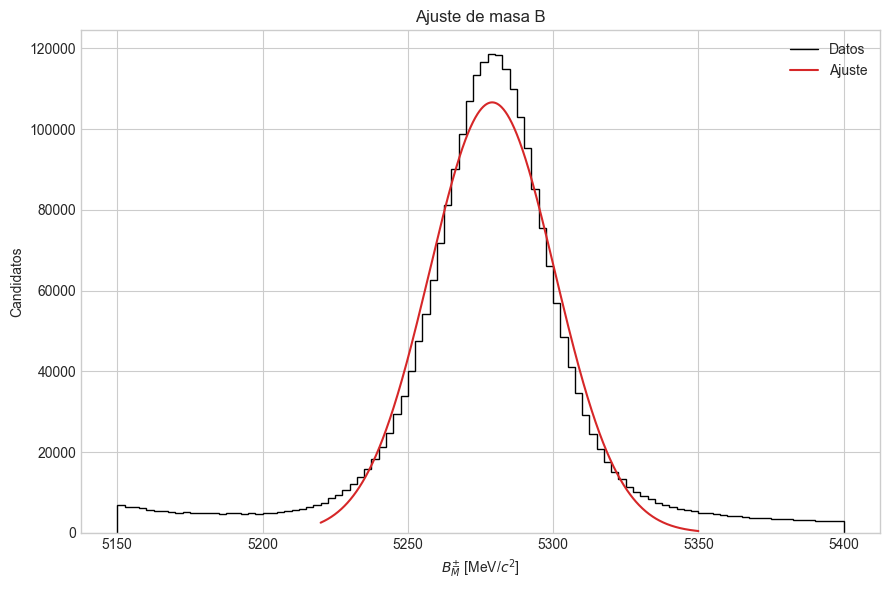

amplitud: 106652 ± 91.3
media: 5279.04 ± 0.0145
sigma: 21.6005 ± 0.0122


In [5]:
fit_counts, _ = np.histogram(b_mass[mask_jpsi], bins=100, range=(5150, 5400))
fit_result = fit_and_plot(
    b_mass[mask_jpsi],
    model_name="gaussian",
    model=gaussian,
    initial_parameters=[max(fit_counts.max(), 1), 5280, 20],
    bounds=([0, 5220, 1], [np.inf, 5350, 100]),
    parameter_names=["amplitud", "media", "sigma"],
    bins=100,
    histogram_range=(5150, 5400),
    fit_range=(5220, 5350),
    title="Ajuste de masa B",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p02_fit_bmass_uproot.png",
)


## Región de señal y bandas laterales

El fondo se escala automáticamente por la anchura de las ventanas.

In [6]:
sidebands = estimate_sideband_background(b_mass, base_mask=mask_jpsi)
print("Candidatos en región de señal:", sidebands["n_signal_region"])
print("Candidatos en sideband izquierda:", sidebands["n_left"])
print("Candidatos en sideband derecha:", sidebands["n_right"])
print(f"Fondo aproximado en región de señal: {sidebands['background_in_signal']:.1f}")
print(f"Señal después de sustraer fondo: {sidebands['signal_after_subtraction']:.1f}")


Candidatos en región de señal: 2154493
Candidatos en sideband izquierda: 321998
Candidatos en sideband derecha: 93369
Fondo aproximado en región de señal: 166146.8
Señal después de sustraer fondo: 1988346.2


## Distribuciones de momento y momento transversal

In [7]:
for column in columns:
    if "_PT" in column or "_P" in column or "_ETA" in column or "_PHI" in column:
        print(column)


Bplus_P
Bplus_PE
Bplus_PT
Bplus_PX
Bplus_PY
Bplus_PZ
J_psi_1S_P
J_psi_1S_PE
J_psi_1S_PT
J_psi_1S_PX
J_psi_1S_PY
J_psi_1S_PZ
Kplus_MC12TuneV2_ProbNNe
Kplus_MC12TuneV2_ProbNNghost
Kplus_MC12TuneV2_ProbNNk
Kplus_MC12TuneV2_ProbNNmu
Kplus_MC12TuneV2_ProbNNp
Kplus_MC12TuneV2_ProbNNpi
Kplus_MC12TuneV3_ProbNNe
Kplus_MC12TuneV3_ProbNNghost
Kplus_MC12TuneV3_ProbNNk
Kplus_MC12TuneV3_ProbNNmu
Kplus_MC12TuneV3_ProbNNp
Kplus_MC12TuneV3_ProbNNpi
Kplus_MC12TuneV4_ProbNNe
Kplus_MC12TuneV4_ProbNNghost
Kplus_MC12TuneV4_ProbNNk
Kplus_MC12TuneV4_ProbNNmu
Kplus_MC12TuneV4_ProbNNp
Kplus_MC12TuneV4_ProbNNpi
Kplus_MC15TuneV1_ProbNNe
Kplus_MC15TuneV1_ProbNNghost
Kplus_MC15TuneV1_ProbNNk
Kplus_MC15TuneV1_ProbNNmu
Kplus_MC15TuneV1_ProbNNp
Kplus_MC15TuneV1_ProbNNpi
Kplus_P
Kplus_PE
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
Kplus_PT
Kplus_PX
Kplus_PY
Kplus_PZ
Kplus_ProbNNd
Kplus_ProbNNe
Kplus_ProbNNghost
Kplus_ProbNNk
Kplus_ProbNNmu
Kplus_ProbNNp
Kplus_ProbNNpi
muminus_MC12TuneV2_ProbNNe
muminus_MC12

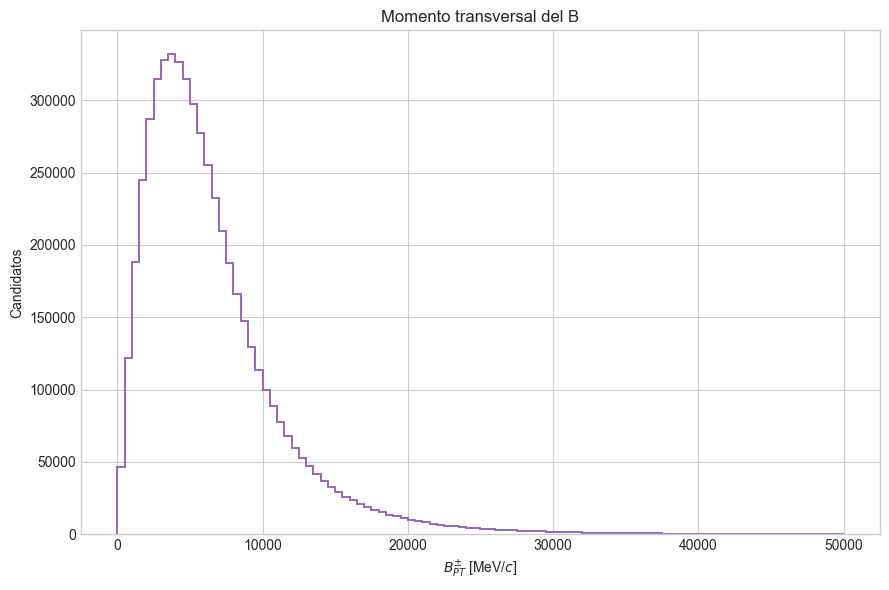

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Momento transversal del B'}, xlabel='$B^{\\pm}_{PT}$ [MeV/$c$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p02_bplus_pt_uproot.png'))

In [8]:
plot_hist1d(
    b_pt,
    bins=100,
    value_range=(0, 50_000),
    title="Momento transversal del B",
    xlabel=r"$B^{\pm}_{PT}$ [MeV/$c$]",
    filename="p02_bplus_pt_uproot.png",
    color="tab:purple",
)


## Relación entre masa y momento transversal

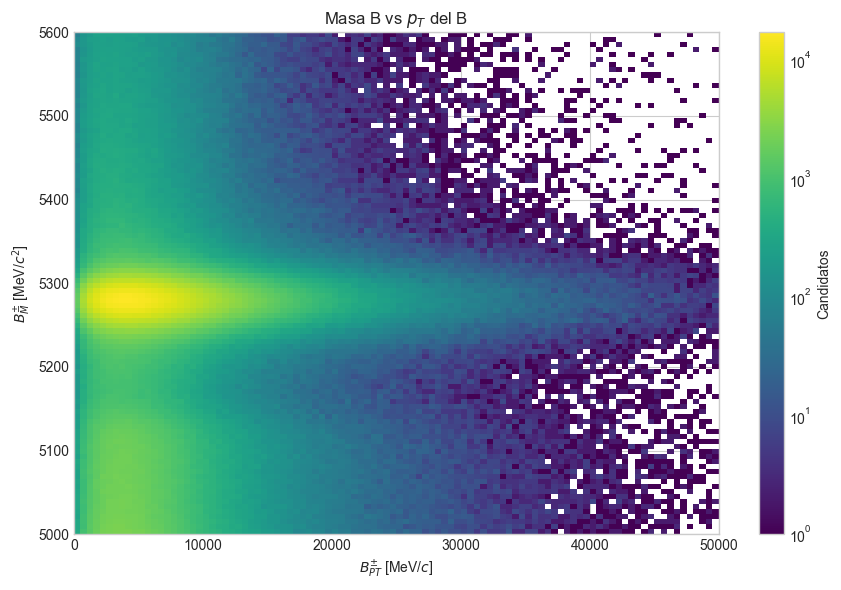

(<Figure size 900x600 with 2 Axes>,
 <Axes: title={'center': 'Masa B vs $p_T$ del B'}, xlabel='$B^{\\pm}_{PT}$ [MeV/$c$]', ylabel='$B^{\\pm}_M$ [MeV/$c^2$]'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p02_bmass_vs_pt_uproot.png'))

In [9]:
plot_hist2d(
    b_pt,
    b_mass,
    bins=(100, 100),
    value_range=((0, 50_000), (5000, 5600)),
    title=r"Masa B vs $p_T$ del B",
    xlabel=r"$B^{\pm}_{PT}$ [MeV/$c$]",
    ylabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p02_bmass_vs_pt_uproot.png",
    log_z=True,
)


## Calidad del vértice

In [10]:
for column in columns:
    if "CHI2" in column or "VERTEX" in column or "FD" in column or "IP" in column:
        print(column)


Bplus_ENDVERTEX_CHI2
Bplus_ENDVERTEX_COV_
Bplus_ENDVERTEX_NDOF
Bplus_ENDVERTEX_X
Bplus_ENDVERTEX_XERR
Bplus_ENDVERTEX_Y
Bplus_ENDVERTEX_YERR
Bplus_ENDVERTEX_Z
Bplus_ENDVERTEX_ZERR
Bplus_FDCHI2_OWNPV
Bplus_FD_OWNPV
Bplus_IPCHI2_OWNPV
Bplus_IP_OWNPV
Bplus_OWNPV_CHI2
J_psi_1S_ENDVERTEX_CHI2
J_psi_1S_ENDVERTEX_COV_
J_psi_1S_ENDVERTEX_NDOF
J_psi_1S_ENDVERTEX_X
J_psi_1S_ENDVERTEX_XERR
J_psi_1S_ENDVERTEX_Y
J_psi_1S_ENDVERTEX_YERR
J_psi_1S_ENDVERTEX_Z
J_psi_1S_ENDVERTEX_ZERR
J_psi_1S_FDCHI2_ORIVX
J_psi_1S_FDCHI2_OWNPV
J_psi_1S_FD_ORIVX
J_psi_1S_FD_OWNPV
J_psi_1S_IPCHI2_OWNPV
J_psi_1S_IP_OWNPV
J_psi_1S_ORIVX_CHI2
J_psi_1S_OWNPV_CHI2
Kplus_IPCHI2_OWNPV
Kplus_IP_OWNPV
Kplus_ORIVX_CHI2
Kplus_OWNPV_CHI2
muminus_IPCHI2_OWNPV
muminus_IP_OWNPV
muminus_ORIVX_CHI2
muminus_OWNPV_CHI2
muplus_IPCHI2_OWNPV
muplus_IP_OWNPV
muplus_ORIVX_CHI2
muplus_OWNPV_CHI2


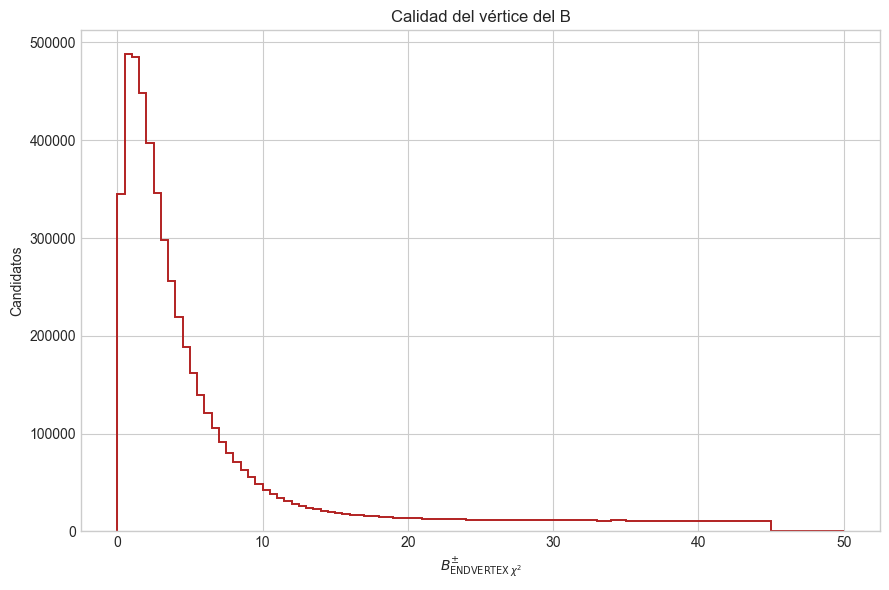

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Calidad del vértice del B'}, xlabel='$B^{\\pm}_{\\mathrm{ENDVERTEX}\\,\\chi^2}$', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p02_vertex_chi2_B_uproot.png'))

In [11]:
plot_hist1d(
    b_vertex_chi2,
    bins=100,
    value_range=(0, 50),
    title="Calidad del vértice del B",
    xlabel=r"$B^{\pm}_{\mathrm{ENDVERTEX}\,\chi^2}$",
    filename="p02_vertex_chi2_B_uproot.png",
    color="firebrick",
)


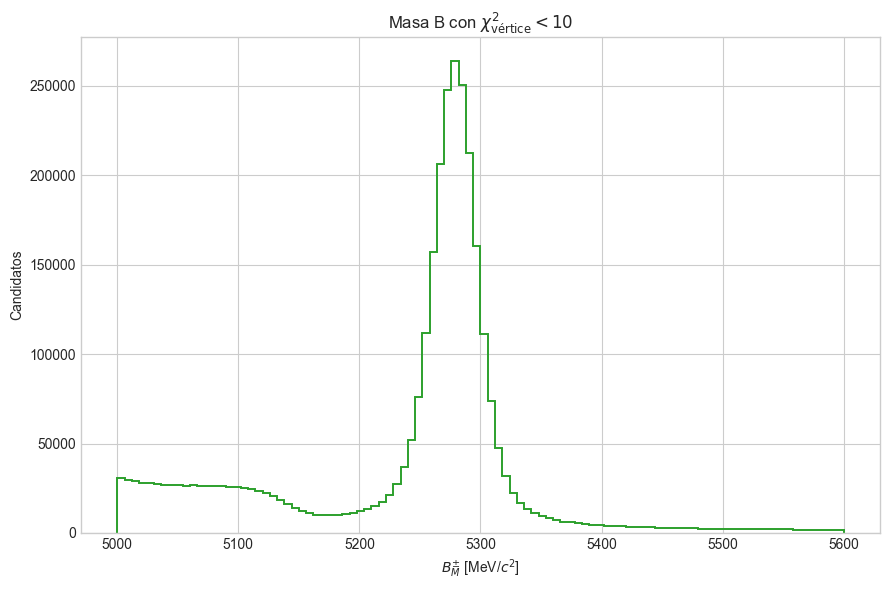

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Masa B con $\\chi^2_{\\mathrm{vértice}} < 10$'}, xlabel='$B^{\\pm}_M$ [MeV/$c^2$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p02_vertex_chi2_B_corte_uproot.png'))

In [12]:
mask_good_vertex = b_vertex_chi2 < 10
plot_hist1d(
    b_mass[mask_good_vertex],
    bins=100,
    value_range=(5000, 5600),
    title=r"Masa B con $\chi^2_{\mathrm{vértice}} < 10$",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p02_vertex_chi2_B_corte_uproot.png",
    color="tab:green",
)


## Identificación de partículas (PID)

In [13]:
for column in columns:
    if "PID" in column or "ProbNN" in column or "DLL" in column:
        print(column)


Kplus_MC12TuneV2_ProbNNe
Kplus_MC12TuneV2_ProbNNghost
Kplus_MC12TuneV2_ProbNNk
Kplus_MC12TuneV2_ProbNNmu
Kplus_MC12TuneV2_ProbNNp
Kplus_MC12TuneV2_ProbNNpi
Kplus_MC12TuneV3_ProbNNe
Kplus_MC12TuneV3_ProbNNghost
Kplus_MC12TuneV3_ProbNNk
Kplus_MC12TuneV3_ProbNNmu
Kplus_MC12TuneV3_ProbNNp
Kplus_MC12TuneV3_ProbNNpi
Kplus_MC12TuneV4_ProbNNe
Kplus_MC12TuneV4_ProbNNghost
Kplus_MC12TuneV4_ProbNNk
Kplus_MC12TuneV4_ProbNNmu
Kplus_MC12TuneV4_ProbNNp
Kplus_MC12TuneV4_ProbNNpi
Kplus_MC15TuneV1_ProbNNe
Kplus_MC15TuneV1_ProbNNghost
Kplus_MC15TuneV1_ProbNNk
Kplus_MC15TuneV1_ProbNNmu
Kplus_MC15TuneV1_ProbNNp
Kplus_MC15TuneV1_ProbNNpi
Kplus_PIDK
Kplus_PIDd
Kplus_PIDe
Kplus_PIDmu
Kplus_PIDp
Kplus_ProbNNd
Kplus_ProbNNe
Kplus_ProbNNghost
Kplus_ProbNNk
Kplus_ProbNNmu
Kplus_ProbNNp
Kplus_ProbNNpi
muminus_MC12TuneV2_ProbNNe
muminus_MC12TuneV2_ProbNNghost
muminus_MC12TuneV2_ProbNNk
muminus_MC12TuneV2_ProbNNmu
muminus_MC12TuneV2_ProbNNp
muminus_MC12TuneV2_ProbNNpi
muminus_MC12TuneV3_ProbNNe
muminus_MC12TuneV3_Pr

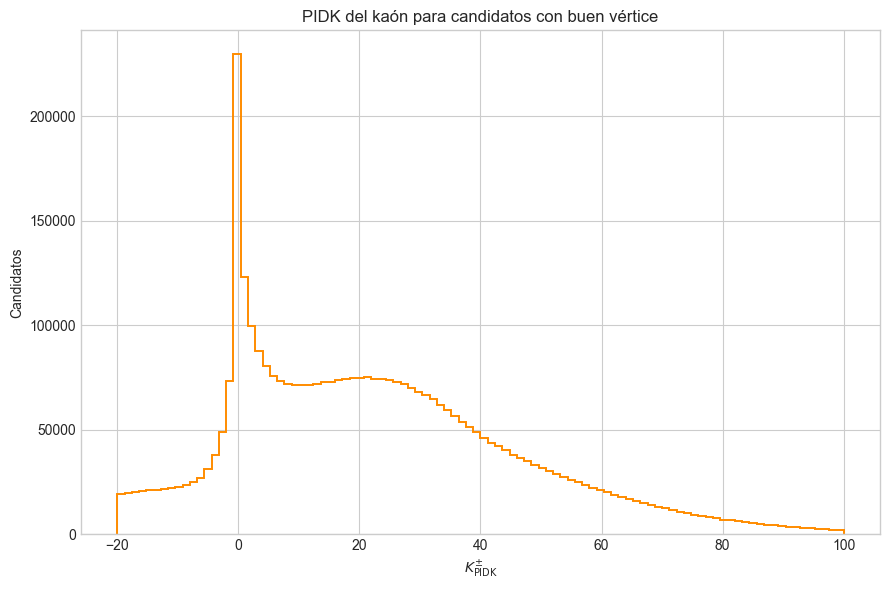

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'PIDK del kaón para candidatos con buen vértice'}, xlabel='$K^{\\pm}_{\\mathrm{PIDK}}$', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p02_kplus_pidk_uproot.png'))

In [14]:
plot_hist1d(
    kplus_pidk[mask_good_vertex],
    bins=100,
    value_range=(-20, 100),
    title="PIDK del kaón para candidatos con buen vértice",
    xlabel=r"$K^{\pm}_{\mathrm{PIDK}}$",
    filename="p02_kplus_pidk_uproot.png",
    color="darkorange",
)


### Corte PID

Se corrigió el original: el histograma ahora sí utiliza la selección `Kplus_PIDK > 0`.

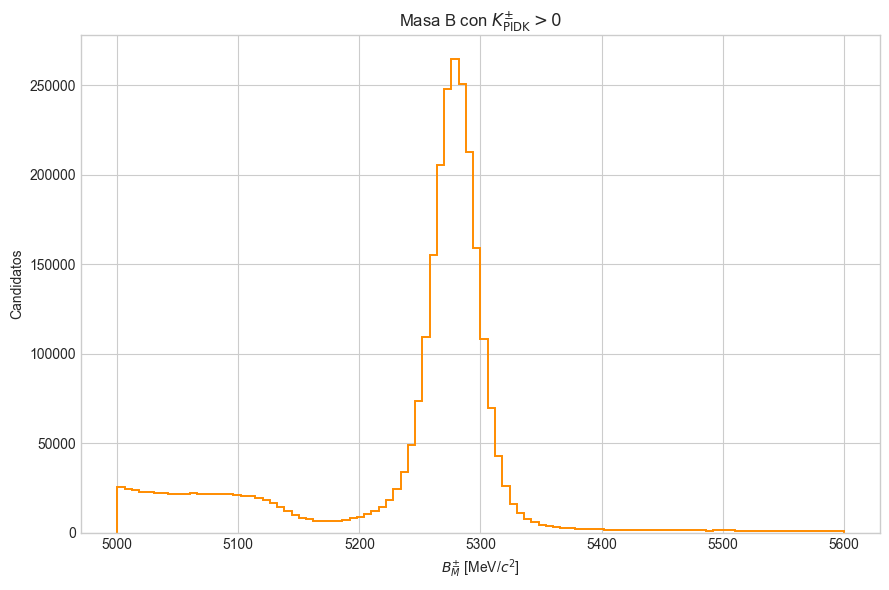

(<Figure size 900x600 with 1 Axes>,
 <Axes: title={'center': 'Masa B con $K^{\\pm}_{\\mathrm{PIDK}} > 0$'}, xlabel='$B^{\\pm}_M$ [MeV/$c^2$]', ylabel='Candidatos'>,
 WindowsPath('C:/Users/mario/Documents/PF/Pruebas/Dec_Bpm/UpROOT/figs/p02_kplus_g_pidk_uproot.png'))

In [15]:
mask_good_pid = kplus_pidk > 0
plot_hist1d(
    b_mass[mask_good_pid],
    bins=100,
    value_range=(5000, 5600),
    title=r"Masa B con $K^{\pm}_{\mathrm{PIDK}} > 0$",
    xlabel=r"$B^{\pm}_M$ [MeV/$c^2$]",
    filename="p02_kplus_g_pidk_uproot.png",
    color="darkorange",
)


## Conversión a Pandas

Uproot ya entregó arreglos NumPy mediante `library="np"`; Pandas puede construir el DataFrame directamente.

In [16]:
df = pd.DataFrame(
    {
        "Bplus_M": b_mass,
        "J_psi_1S_M": jpsi_mass,
    }
)
df.head()


,Bplus_M,J_psi_1S_M
0,4956.729567,3103.313068
1,5156.595195,3106.257555
2,5254.092310,3079.718331
3,5224.640083,3042.170935
4,5312.555129,3136.136955
